## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import coo_matrix
import spacy
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
# Load spaCy model (run once if not downloaded: python -m spacy download en_core_web_sm)
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

## Loading the Dataset

In [2]:
# Load data (limited to 10k rows for efficiency; adjust as needed)
train_data = pd.read_csv('Online Retail.csv', encoding='unicode_escape', nrows=10000)
train_data = train_data[['StockCode', 'Description', 'Quantity', 'CustomerID', 'UnitPrice']]
column_name_mapping = {'StockCode': 'ID', 'Description': 'Description', 'Quantity': 'Quantity', 'CustomerID': 'CID', 'UnitPrice': 'Price'}
train_data.rename(columns=column_name_mapping, inplace=True)
print(train_data.head())  # Quick peek
print(train_data.info())  # Data types and nulls

       ID                          Description  Quantity      CID  Price
0  85123A   WHITE HANGING HEART T-LIGHT HOLDER         6  17850.0   2.55
1   71053                  WHITE METAL LANTERN         6  17850.0   3.39
2  84406B       CREAM CUPID HEARTS COAT HANGER         8  17850.0   2.75
3  84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6  17850.0   3.39
4  84029E       RED WOOLLY HOTTIE WHITE HEART.         6  17850.0   3.39
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           10000 non-null  object 
 1   Description  9958 non-null   object 
 2   Quantity     10000 non-null  int64  
 3   CID          7709 non-null   float64
 4   Price        10000 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 390.8+ KB
None


In [18]:
train_data

,ID,Description,Quantity,CID,Price,cleaned_description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,17850.0,2.55,white hang heart t light holder
1,71053,WHITE METAL LANTERN,6,17850.0,3.39,white metal lantern
2,84406B,CREAM CUPID HEARTS COAT HANGER,8,17850.0,2.75,cream cupid heart coat hanger
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,17850.0,3.39,knit union flag hot water bottle
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,17850.0,3.39,red woolly hottie white heart
...,...,...,...,...,...,...
9995,22622,BOX OF VINTAGE ALPHABET BLOCKS,2,13174.0,9.95,box vintage alphabet block
9996,22623,BOX OF VINTAGE JIGSAW BLOCKS,2,13174.0,4.95,box vintage jigsaw block
9997,21363,HOME SMALL WOOD LETTERS,2,13174.0,4.95,home small wood letter
9998,21556,CERAMIC STRAWBERRY MONEY BOX,2,13174.0,2.55,ceramic strawberry money box


## Exploratory Data Analysis

In [3]:
# Basic stats
print(train_data.describe())  # Numerical summaries (Quantity, Price)
print(train_data['ID'].nunique())  # Unique products
print(train_data['CID'].nunique())  # Unique users

# Handle missing values (for EDA completeness)
print(train_data.isnull().sum())  # Check nulls
train_data['Description'] = train_data['Description'].fillna('Unknown')
train_data['CID'] = train_data['CID'].fillna(0)

           Quantity           CID         Price
count  10000.000000   7709.000000  10000.000000
mean       7.828600  15615.462576      3.837412
std      104.322417   1756.540802     14.310148
min    -9360.000000  12395.000000      0.000000
25%        1.000000  14388.000000      1.250000
50%        2.000000  15605.000000      2.510000
75%        8.000000  17228.000000      4.210000
max     2880.000000  18239.000000    887.520000
2015
323
ID                0
Description      42
Quantity          0
CID            2291
Price             0
dtype: int64


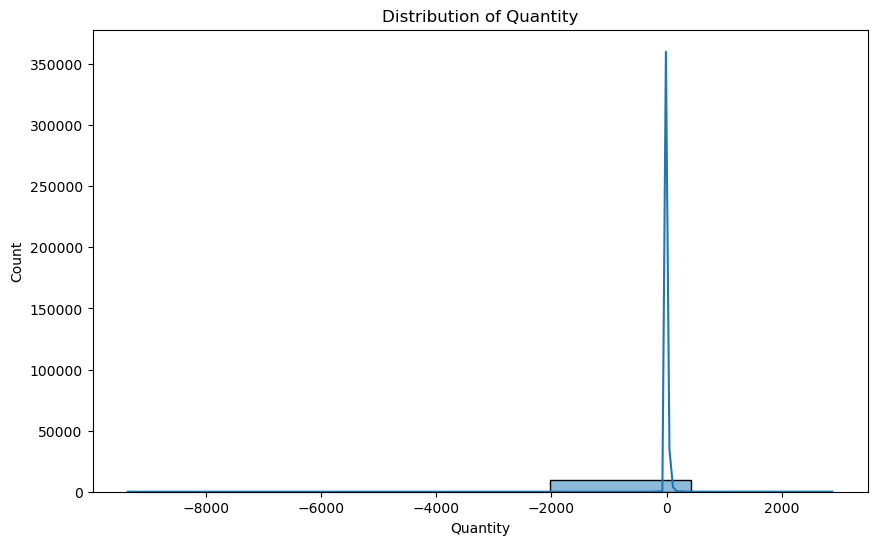

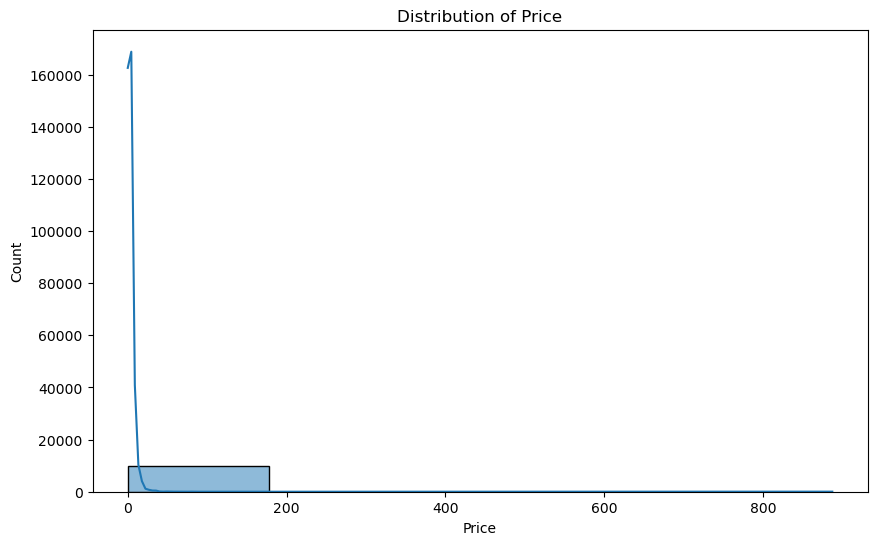

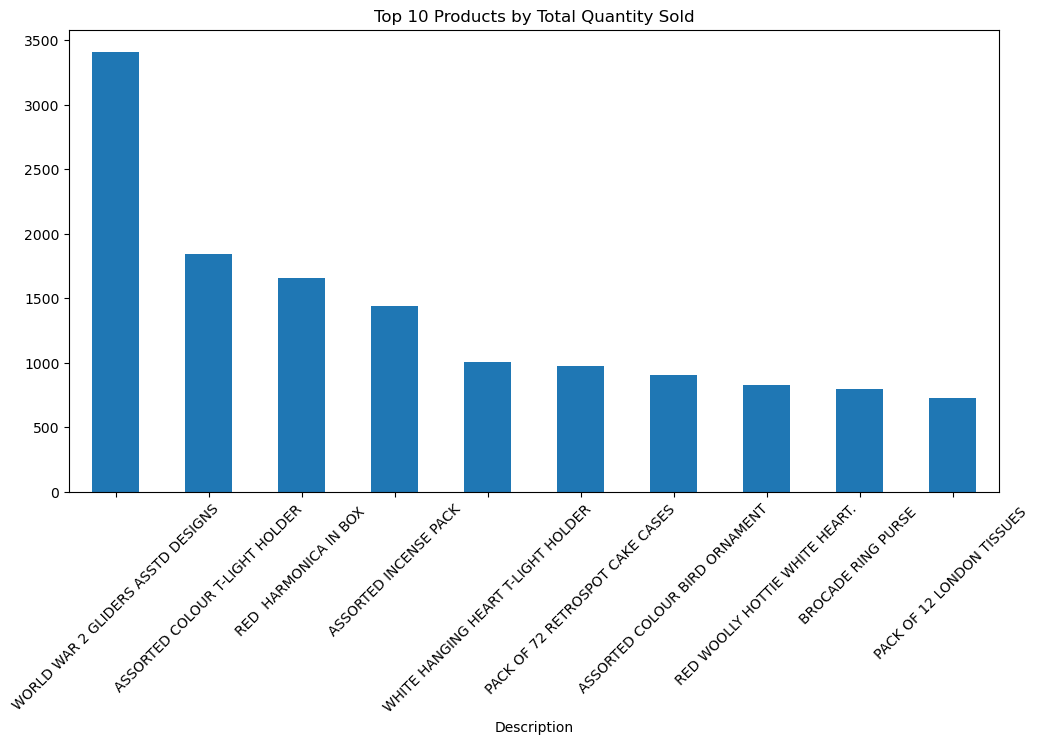

In [6]:
# Visualizations
plt.figure(figsize=(10, 6))
sns.histplot(train_data['Quantity'], bins=5, kde=True)
plt.title('Distribution of Quantity')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(train_data['Price'], bins=5, kde=True)
plt.title('Distribution of Price')
plt.show()

# Top 10 products by quantity
top_products = train_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
top_products.plot(kind='bar')
plt.title('Top 10 Products by Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()

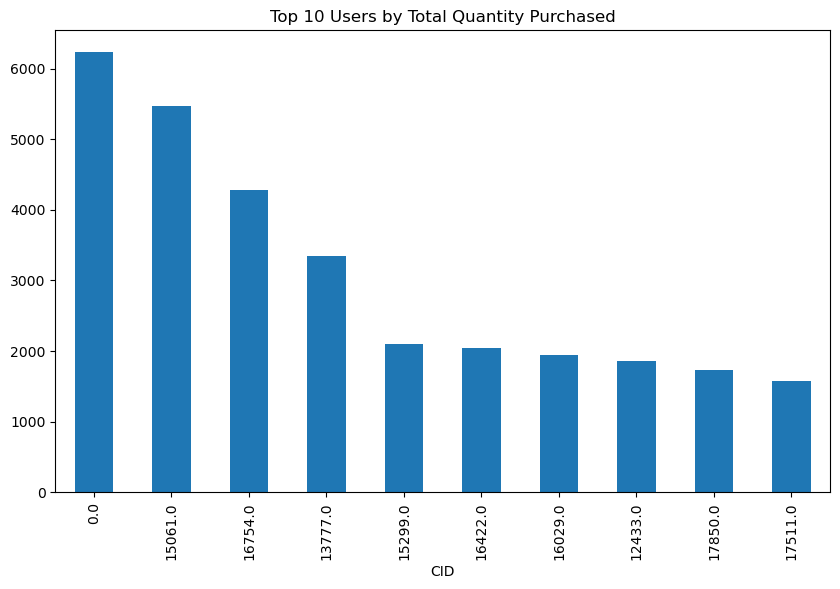

In [7]:
# User behavior: Top users by purchases
top_users = train_data.groupby('CID')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_users.plot(kind='bar')
plt.title('Top 10 Users by Total Quantity Purchased')
plt.show()

## Data Preprocessing

In [8]:
# Preprocessing
train_data.drop_duplicates(inplace=True)
train_data = train_data[train_data['Quantity'] > 0]

# Lemmatization function
def clean_and_lemmatize(text):
    if not isinstance(text, str): text = str(text)
    doc = nlp(text.lower())
    lemmatized = ' '.join([token.lemma_ for token in doc if not token.is_stop and token.is_alpha])
    return lemmatized if lemmatized else 'unknown'

train_data['cleaned_description'] = train_data['Description'].apply(clean_and_lemmatize)
print(train_data.head())  # Verify

       ID                          Description  Quantity      CID  Price  \
0  85123A   WHITE HANGING HEART T-LIGHT HOLDER         6  17850.0   2.55   
1   71053                  WHITE METAL LANTERN         6  17850.0   3.39   
2  84406B       CREAM CUPID HEARTS COAT HANGER         8  17850.0   2.75   
3  84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6  17850.0   3.39   
4  84029E       RED WOOLLY HOTTIE WHITE HEART.         6  17850.0   3.39   

                cleaned_description  
0   white hang heart t light holder  
1               white metal lantern  
2     cream cupid heart coat hanger  
3  knit union flag hot water bottle  
4     red woolly hottie white heart  


## Content Based Recommendation

In [9]:
def get_content_based_recommendations(train_data, item_name, top_n=10):
    tfidf = TfidfVectorizer()
    tfidf_matrix = tfidf.fit_transform(train_data['cleaned_description'])
    cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
    mask = train_data['Description'].str.contains(item_name, case=False, na=False)
    matches = train_data[mask]
    if matches.empty: return pd.DataFrame()
    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    item_indices = [i[0] for i in sim_scores]
    recommendations = train_data.iloc[item_indices].copy()
    recommendations['Similarity_Score'] = [score[1] for score in sim_scores]
    recommendations['Rating'] = recommendations.groupby('ID')['Quantity'].transform('mean')
    return recommendations[['ID', 'Description', 'Rating', 'Price', 'Similarity_Score']]

## Popularity Based Recommendation

In [10]:
def popularity_based_recommendations(train_data, top_n=10):
    aggregated = train_data.groupby('ID').agg({'Quantity': 'sum', 'Price': 'mean', 'Description': 'first'}).reset_index()
    aggregated['Weighted_Score'] = aggregated['Quantity']  # Proxy for popularity
    return aggregated.sort_values('Weighted_Score', ascending=False).head(top_n)

## Collaborative Filtering Recommendation

In [11]:
def collaborative_filtering_recommendations(train_data, target_user_id, top_n=10):
    user_item_df = train_data.groupby(['CID', 'ID'])['Quantity'].sum().unstack().fillna(0)
    user_item_matrix = np.log1p(user_item_df.values)
    user_map = {user: idx for idx, user in enumerate(user_item_df.index)}
    product_map = {prod: idx for idx, prod in enumerate(user_item_df.columns)}
    if target_user_id not in user_map: return pd.DataFrame()
    user_index = user_map[target_user_id]
    user_ratings = user_item_matrix[user_index]
    similar_users = cosine_similarity([user_ratings], user_item_matrix)[0]
    similar_indices = similar_users.argsort()[-top_n-1:-1]
    recommended = user_item_matrix[similar_indices].mean(axis=0)
    recommended_items = np.argsort(recommended)[::-1][:top_n]
    rec_ids = [list(product_map.keys())[list(product_map.values()).index(i)] for i in recommended_items]
    rec_details = train_data[train_data['ID'].isin(rec_ids)][['ID', 'Description', 'Price']].drop_duplicates('ID')
    rec_details['Rating'] = [recommended[i] for i in recommended_items]
    return rec_details

## LLM Setup For Explaination

In [15]:
generator = pipeline('text-generation', model='gpt2', device='cpu')  # Or change to 'gpt2' for better quality

def generate_explanation(product_desc, user_behavior):
    # Format user_behavior nicely, limiting to top 3 to keep prompt short
    behavior_str = ', '.join([f"{desc} ({count} times)" for desc, count in list(user_behavior.items())[:3]])
    prompt = f"The product '{product_desc}' is recommended to this user based on their behavior: {behavior_str}."
    
    # Generate with improved params for longer, non-repetitive text
    response = generator(
        prompt,
        max_new_tokens=150,          # Increased for fuller explanations
        min_new_tokens=50,           # Force at least 50 new tokens
        do_sample=True,
        temperature=0.8,             # Slightly higher for creativity
        top_p=0.95,                  # Nucleus sampling for better variety
        no_repeat_ngram_size=3,      # Avoid repetition of 3-word phrases
        truncation=True
    )[0]['generated_text']
    
    # Debug: Print full response to check (remove after testing)
    print(f"{response}")
    
    # Extract just the new explanation, with fallback if too short
    explanation = response[len(prompt):].strip()
    if len(explanation) < 20:  # If too short, use fallback
        explanation = "This product matches your recent purchases and interests in similar items."
    return explanation


Device set to use cpu


## Hybrid Recommendations

In [16]:
# Hybrid with LLM
def hybrid_recommendations(train_data, target_user_id, item_name, top_n=10):
    content_rec = get_content_based_recommendations(train_data, item_name, top_n)
    collab_rec = collaborative_filtering_recommendations(train_data, target_user_id, top_n)
    pop_rec = popularity_based_recommendations(train_data, top_n)
    hybrid_rec = pd.concat([content_rec, collab_rec]).drop_duplicates('ID').head(top_n)
    user_behavior = train_data[train_data['CID'] == target_user_id]['Description'].value_counts().head(3).to_dict()
    hybrid_rec['Explanation'] = hybrid_rec['Description'].apply(lambda desc: generate_explanation(desc, user_behavior))
    return hybrid_rec[['ID', 'Description', 'Rating', 'Price', 'Explanation']]


## Example Usage

In [17]:
target_user_id = 17850.0
item_name = "WHITE HANGING HEART T-LIGHT HOLDER"
hybrid_rec = hybrid_recommendations(train_data, target_user_id, item_name)
print(hybrid_rec)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The product 'WHITE HANGING HEART T-LIGHT HOLDER' is recommended to this user based on their behavior: WHITE HANGING HEART T-LIGHT HOLDER (4 times), GLASS STAR FROSTED T-LIGHT HOLDER (4 times), WHITE METAL LANTERN (3 times).

To help you avoid this product (it is not 100% safe), please read our instructions on how to remove it from your system.

Please refer to our WARNINGS for more information.
.
, this product is not suitable for children under 5 years of age.
 I have tried using this product twice and it does not work the first time. I am unsure about its accuracy. I understand that the product works fine with a little bit of time and that you will need to wait until your next use before you buy it again. I have also tried using the product twice, it does indeed not work. It is only good for use with light bulbs. If you are unsure if this product works or not, please do


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The product 'KNITTED UNION FLAG HOT WATER BOTTLE' is recommended to this user based on their behavior: WHITE HANGING HEART T-LIGHT HOLDER (4 times), GLASS STAR FROSTED T-LIGHT HOLDER (4 times), WHITE METAL LANTERN (3 times). The product is made of highly durable PVC. These items are available in a variety of colors, styles, and sizes. The plastic packaging can be very difficult to work with, so please have the product in your home for a little while. The quality of the PVC is very good, even after the product has been used for years. It can also be difficult to clean, so be sure to use a mild cleanser or a mild detergent (or something that will wash down the surface of the product. It is a very important ingredient in the product, and not recommended in the US unless you have experienced a lot of washing with this product). The plastic can be used to clean the product and to hold the product together. It's important to


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

The product 'WOODEN FRAME ANTIQUE WHITE ' is recommended to this user based on their behavior: WHITE HANGING HEART T-LIGHT HOLDER (4 times), GLASS STAR FROSTED T-LIGHT HOLDER (4 times), WHITE METAL LANTERN (3 times). It can be mixed with water to make a color film.

The product "WOODEN FABRIC PINK'is also recommended to the user based upon their behavior; FABRILLING (4) and (5) color film can be used.
 "RED HAPPINESS ANTI-BIG T-BONNAGE (6 times) and WHITE PINK (7) can be added to water in an effort to make it feel more orange.
- "CARE IN THE DARK GREEN " is recommended.
, is recommended. This product may or may not be formulated to the same standard as the one shown here. For more information contact the manufacturer.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The product 'HAND WARMER SCOTTY DOG DESIGN' is recommended to this user based on their behavior: WHITE HANGING HEART T-LIGHT HOLDER (4 times), GLASS STAR FROSTED T-LIGHT HOLDER (4 times), WHITE METAL LANTERN (3 times). The product is intended for adult users, children and pets. A'small' sized adult sized product (3.5 mm) is recommended. WARNING: This product may cause cancer, birth defects or other reproductive harm. Some states do not allow the sale or rental of this product, so the user is strongly advised to consult a health care professional for medical advice. Please read labels carefully. Product may contain: Nicotine. Do not exceed 4 mg/ml, Nicotine is a known carcinogen. Do NOT use in any form. Nicotine is not intended for any person under the age of 18 years.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The product 'HAND WARMER OWL DESIGN' is recommended to this user based on their behavior: WHITE HANGING HEART T-LIGHT HOLDER (4 times), GLASS STAR FROSTED T-LIGHT HOLDER (4 times), WHITE METAL LANTERN (3 times).

If you are using a high contrast product and your screen is at a lower resolution, this product does not work. You may have to adjust the contrast settings of this product and you should be aware of that fact. This is a product which is not for use in an enclosed area where you are not allowed to store your product.

Product Description


This product has a low contrast feature that reduces the contrast in your product to a very good amount. It is recommended that this product be used in an outdoor environment with very low glare. This product has very high contrast and color.
.


If this product is not working for you, please try another product. It may not work for you. Please try another one.
The product 'SOLDIERS EGG CUP ' is recommended to this user based on their behavio